In [1]:
import pandas as pd

TRAIN_PATH = "../data/processed/train.csv"
TEST_PATH = "../data/processed/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(train_df.shape)
print(test_df.shape)

(5090096, 20)
(1272524, 20)


In [2]:
X_train = train_df.drop(columns=["isFraud"])
y_train = train_df["isFraud"]

X_test = test_df.drop(columns=["isFraud"])
y_test = test_df["isFraud"]
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(5090096, 19)
(5090096,)
(1272524, 19)
(1272524,)


In [3]:
from sklearn.dummy import DummyClassifier
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train,y_train)
dummy_predictions = dummy_model.predict(X_test)

In [4]:
from sklearn.metrics import classification_report
print(classification_report(y_test,dummy_predictions,digits = 4))

d:\recommendation_project\recsys_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0     0.9987    1.0000    0.9994   1270881
           1     0.0000    0.0000    0.0000      1643

    accuracy                         0.9987   1272524
   macro avg     0.4994    0.5000    0.4997   1272524
weighted avg     0.9974    0.9987    0.9981   1272524



d:\recommendation_project\recsys_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\recommendation_project\recsys_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5090096, 19)
(1272524, 19)


In [6]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss="log_loss",
    class_weight="balanced",
    random_state=42,
    max_iter=20,
    n_jobs=-1
)

sgd_model.fit(X_train_scaled, y_train)

,loss,'log_loss'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,20
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,-1


In [7]:
y_pred = sgd_model.predict(X_test_scaled)

In [8]:
print(classification_report(
    y_test,
    y_pred,
    digits=4
) )

              precision    recall  f1-score   support

           0     1.0000    0.9617    0.9804   1270881
           1     0.0319    0.9763    0.0617      1643

    accuracy                         0.9617   1272524
   macro avg     0.5159    0.9690    0.5211   1272524
weighted avg     0.9987    0.9617    0.9793   1272524



In [9]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[1222164   48717]
 [     39    1604]]


In [10]:
y_scores =sgd_model.decision_function(X_test_scaled)

In [11]:
from sklearn.metrics import roc_auc_score, average_precision_score
roc_auc = roc_auc_score(y_test,y_scores)
avg_precision = average_precision_score(y_test,y_scores)
print(roc_auc)
print(avg_precision)

0.995647699321504
0.6218185339356302


In [12]:
X_train_xgb = X_train.sample(
    n=1_000_000,
    random_state=42
)

y_train_xgb = y_train.loc[X_train_xgb.index]

print("X_train_xgb shape:", X_train_xgb.shape)
print("y_train_xgb shape:", y_train_xgb.shape)
print("\nClass distribution:")
print(y_train_xgb.value_counts())


X_train_xgb shape: (1000000, 19)
y_train_xgb shape: (1000000,)

Class distribution:
isFraud
0    998783
1      1217
Name: count, dtype: int64


In [13]:
y_train_xgb.value_counts()

isFraud
0    998783
1      1217
Name: count, dtype: int64

In [14]:
import xgboost as xgb
print(xgb, xgb.__version__)

<module 'xgboost' from 'd:\\recommendation_project\\recsys_env\\lib\\site-packages\\xgboost\\__init__.py'> 2.1.4


In [15]:
scale_pos_weight = (y_train_xgb == 0).sum() / (y_train_xgb == 1).sum()
print("Scale pos weight:", scale_pos_weight)

Scale pos weight: 820.6926869350863


In [16]:
xgb_model = xgb.XGBClassifier(
    n_estimators = 300,
    max_depth = 6,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    tree_method ="hist",
    random_state=42,
    n_jobs=-1
)

In [17]:
xgb_model.fit(X_train_xgb,y_train_xgb)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


In [18]:
y_xgb_proba = xgb_model.predict_proba(X_test)[:,1]

In [19]:
y_xgb_pred = (y_xgb_proba >= 0.5).astype(int)
print(classification_report(
    y_test,
    y_xgb_pred,
    digits=4
))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9832    0.9976    0.9903      1643

    accuracy                         1.0000   1272524
   macro avg     0.9916    0.9988    0.9952   1272524
weighted avg     1.0000    1.0000    1.0000   1272524



In [20]:
cm_xgb = confusion_matrix(y_test,y_xgb_pred)
print(cm_xgb)

[[1270853      28]
 [      4    1639]]


In [21]:
roc_auc_xgb = roc_auc_score(y_test,y_xgb_proba)
pr_auc_xgb = average_precision_score(y_test,y_xgb_proba)
print(roc_auc_xgb)
print(pr_auc_xgb)

0.9998662287785302
0.9978041945412573


In [22]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index = X_train_xgb.columns
).sort_values(ascending=False)

print(feature_importance)

origin_balance_error                   0.342274
amount_to_origin_balance_ratio         0.205512
Origin_balance_change                  0.198654
newbalanceOrig                         0.150143
type_TRANSFER                          0.026688
amount                                 0.014738
type_CASH_IN                           0.013368
isFlaggedFraud                         0.011621
type_PAYMENT                           0.010963
type_CASH_OUT                          0.007233
oldbalanceDest                         0.004988
oldbalanceOrg                          0.002577
log_amount                             0.002452
destination_balance_error              0.002067
amount_to_destination_balance_ratio    0.001885
Destination_balance_change             0.001646
newbalanceDest                         0.001428
step                                   0.001362
type_DEBIT                             0.000402
dtype: float32


In [23]:
print(feature_importance.head(10))

origin_balance_error              0.342274
amount_to_origin_balance_ratio    0.205512
Origin_balance_change             0.198654
newbalanceOrig                    0.150143
type_TRANSFER                     0.026688
amount                            0.014738
type_CASH_IN                      0.013368
isFlaggedFraud                    0.011621
type_PAYMENT                      0.010963
type_CASH_OUT                     0.007233
dtype: float32


In [24]:
X_train_xgb_no_error = X_train_xgb.drop(
    columns=["origin_balance_error"]
)

X_test_no_error = X_test.drop(
    columns=["origin_balance_error"]
)

print(X_train_xgb_no_error.shape)
print(X_test_no_error.shape)

(1000000, 18)
(1272524, 18)


In [25]:
xgb_model_no_error = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

In [26]:
xgb_model_no_error.fit(
    X_train_xgb_no_error,
    y_train_xgb
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


In [27]:
y_proba_no_error = xgb_model_no_error.predict_proba(
    X_test_no_error
)[:, 1]

In [28]:

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_proba_no_error)
)

print(
    "PR-AUC:",
    average_precision_score(y_test, y_proba_no_error)
)

ROC-AUC: 0.999672632336243
PR-AUC: 0.9794288888140246


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

results = []

for threshold in thresholds:
    predictions = (y_xgb_proba >= threshold).astype(int)
    
    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )
    
    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )
    
    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )
    
    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results = pd.DataFrame(results)
print(threshold_results)

    threshold  precision    recall        f1
0        0.01   0.891730  0.997565  0.941683
1        0.05   0.969249  0.997565  0.983203
2        0.10   0.980263  0.997565  0.988839
3        0.20   0.983203  0.997565  0.990332
4        0.30   0.983203  0.997565  0.990332
5        0.40   0.983203  0.997565  0.990332
6        0.50   0.983203  0.997565  0.990332
7        0.60   0.984384  0.997565  0.990931
8        0.70   0.985568  0.997565  0.991531
9        0.80   0.986161  0.997565  0.991831
10       0.90   0.986747  0.996957  0.991826


In [30]:
best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print(best_row)

threshold    0.800000
precision    0.986161
recall       0.997565
f1           0.991831
Name: 9, dtype: float64


In [31]:
high_recall = threshold_results[
    threshold_results["recall"] >= 0.99
]

print(high_recall)

    threshold  precision    recall        f1
0        0.01   0.891730  0.997565  0.941683
1        0.05   0.969249  0.997565  0.983203
2        0.10   0.980263  0.997565  0.988839
3        0.20   0.983203  0.997565  0.990332
4        0.30   0.983203  0.997565  0.990332
5        0.40   0.983203  0.997565  0.990332
6        0.50   0.983203  0.997565  0.990332
7        0.60   0.984384  0.997565  0.990931
8        0.70   0.985568  0.997565  0.991531
9        0.80   0.986161  0.997565  0.991831
10       0.90   0.986747  0.996957  0.991826


In [32]:
import shap
print(shap.__version__)

0.49.1


In [33]:
X_shap = X_test.sample(
    n=2000,
    random_state=42
)
print(X_shap.shape)

(2000, 19)


In [34]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

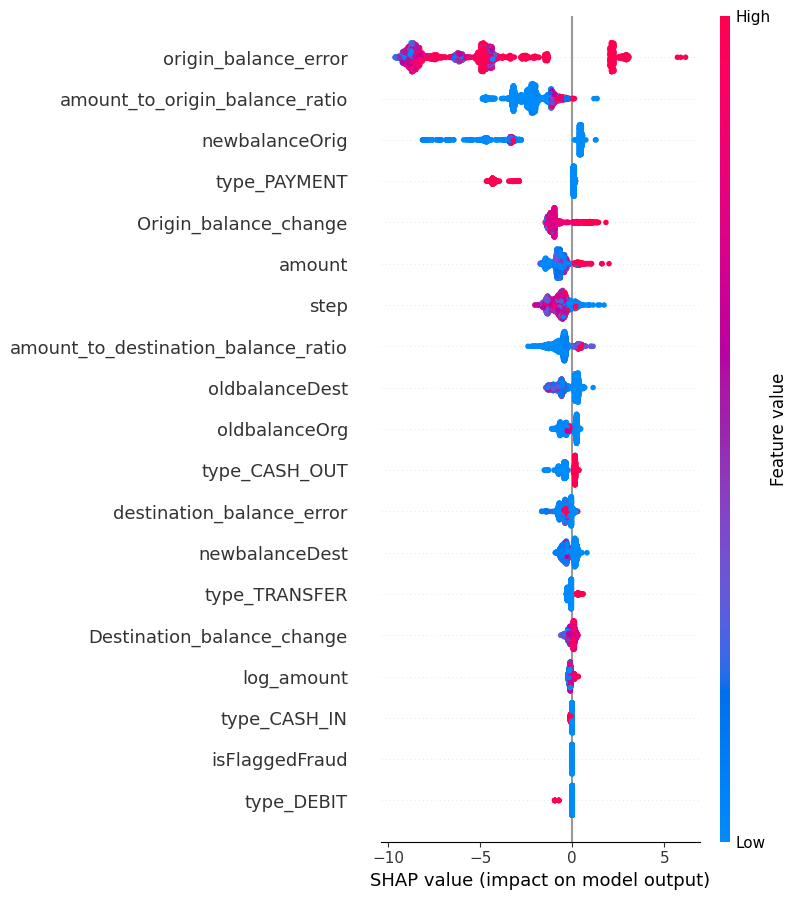

In [35]:
shap.summary_plot(
    shap_values,
    X_shap
)

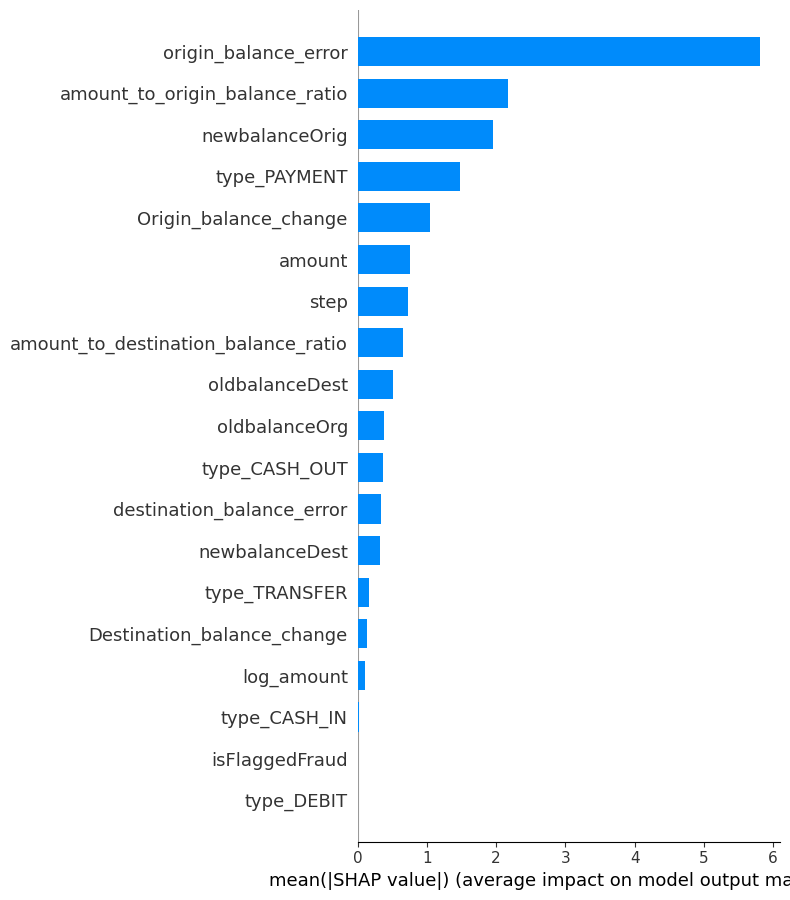

In [36]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)

In [37]:
transaction  = X_test.iloc[[0]]

In [38]:
transaction_shap = explainer.shap_values(transaction)

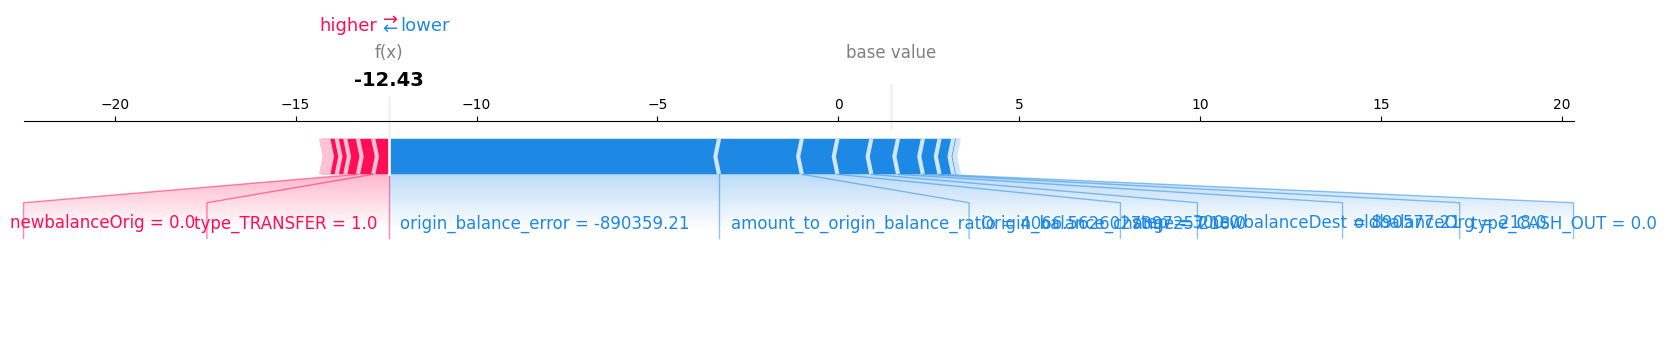

In [39]:
shap.force_plot(
    explainer.expected_value,
    transaction_shap[0],
    transaction.iloc[0],
    matplotlib = True
)

In [40]:
transaction_probability =xgb_model.predict_proba(transaction)[0,1]
print("Fraud probability:", transaction_probability)
print("Predicted class:", int(transaction_probability >= 0.5))

Fraud probability: 4.007624e-06
Predicted class: 0


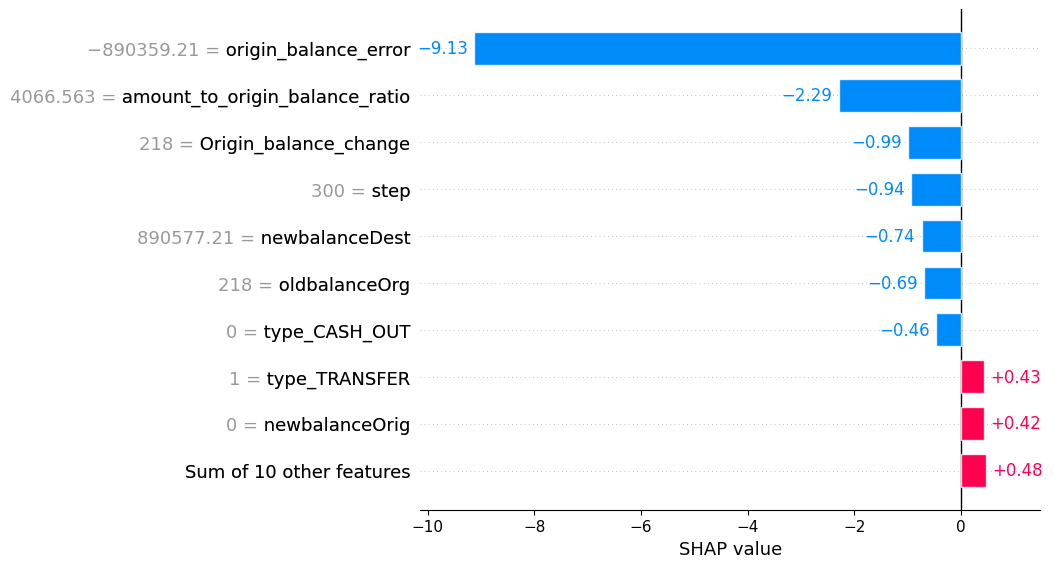

In [41]:
shap_result = explainer(transaction)

shap.plots.bar(
    shap_result[0]
)

In [42]:
fraud_indices = y_test[y_test == 1].index

fraud_transaction = X_test.loc[[fraud_indices[0]]]

fraud_probability = xgb_model.predict_proba(
    fraud_transaction
)[0, 1]

print("Fraud probability:", fraud_probability)
print("Actual label:", y_test.loc[fraud_indices[0]])

Fraud probability: 0.9999969
Actual label: 1


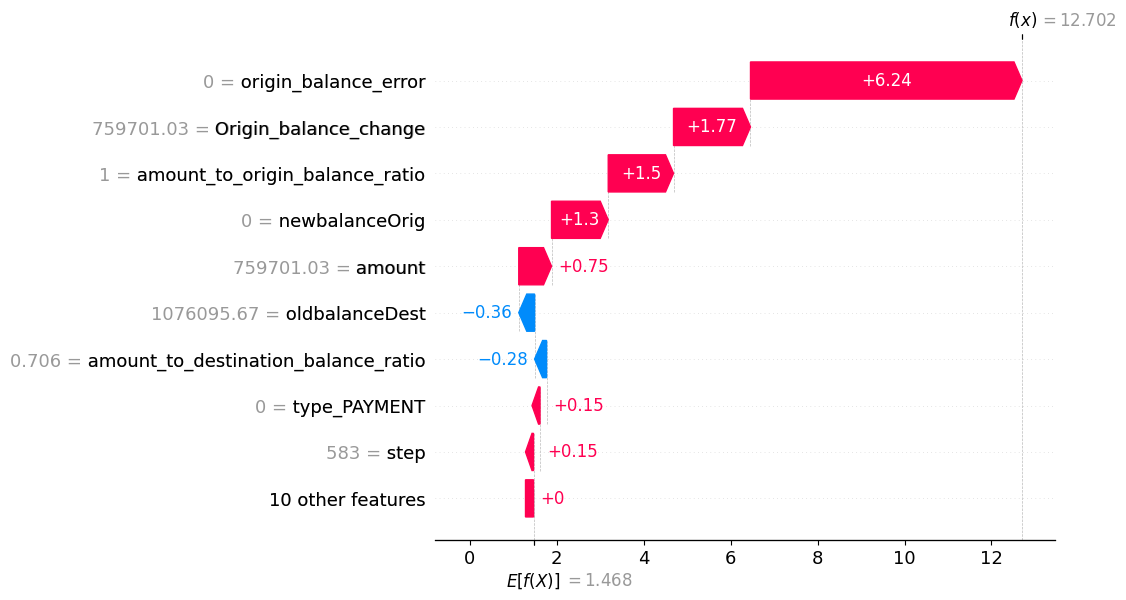

In [43]:
fraud_shap = explainer(fraud_transaction)

shap.plots.waterfall(
    fraud_shap[0]
)

In [44]:
import joblib
from pathlib import Path

MODEL_PATH = Path("../models/xgb_fraud_model.pkl")

joblib.dump(xgb_model, MODEL_PATH)

print("Model saved successfully!")
print(MODEL_PATH)

Model saved successfully!
..\models\xgb_fraud_model.pkl


In [45]:
feature_columns = X_train_xgb.columns.tolist()

print("Number of features:", len(feature_columns))
print("\nFeature columns:")
for i, feature in enumerate(feature_columns):
    print(i, feature)

Number of features: 19

Feature columns:
0 step
1 amount
2 oldbalanceOrg
3 newbalanceOrig
4 oldbalanceDest
5 newbalanceDest
6 isFlaggedFraud
7 Origin_balance_change
8 Destination_balance_change
9 amount_to_origin_balance_ratio
10 amount_to_destination_balance_ratio
11 origin_balance_error
12 destination_balance_error
13 log_amount
14 type_CASH_IN
15 type_CASH_OUT
16 type_DEBIT
17 type_PAYMENT
18 type_TRANSFER


In [46]:
import joblib
from pathlib import Path

FEATURE_PATH = Path("../models/feature_columns.pkl")

joblib.dump(feature_columns, FEATURE_PATH)

print("Feature list saved!")
print(FEATURE_PATH)
print("Exists:", FEATURE_PATH.exists())

Feature list saved!
..\models\feature_columns.pkl
Exists: True


In [48]:
import importlib.util
from pathlib import Path

preprocessing_path = Path("../src/preprocessing.py").resolve()
spec = importlib.util.spec_from_file_location(
    "fraud_preprocessing",
    preprocessing_path
)
preprocessing = importlib.util.module_from_spec(spec)
spec.loader.exec_module(preprocessing)
create_features = preprocessing.create_features

sample_transaction = test_df.iloc[[0]].drop(columns=["isFraud"])

print("Raw transaction:")
print(sample_transaction)

if "type" in sample_transaction.columns:
    processed_transaction = create_features(sample_transaction)
else:
    processed_transaction = sample_transaction.copy()

print("\nProcessed transaction:")
print(processed_transaction)

print("\nShape:", processed_transaction.shape)

Raw transaction:
   step     amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0   300  890577.21          218.0             0.0             0.0   

   newbalanceDest  isFlaggedFraud  Origin_balance_change  \
0       890577.21               0                  218.0   

   Destination_balance_change  amount_to_origin_balance_ratio  \
0                  -890577.21                     4066.562603   

   amount_to_destination_balance_ratio  origin_balance_error  \
0                            890577.21            -890359.21   

   destination_balance_error  log_amount  type_CASH_IN  type_CASH_OUT  \
0                        0.0   13.699626             0              0   

   type_DEBIT  type_PAYMENT  type_TRANSFER  
0           0             0              1  

Processed transaction:
   step     amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0   300  890577.21          218.0             0.0             0.0   

   newbalanceDest  isFlaggedFraud  Origin_balance_change  \
0  

In [50]:
probability = xgb_model.predict_proba(processed_transaction)[0, 1]

print("Fraud probability:", probability)
prediction = int(probability >= 0.5)

print("Prediction:", prediction)

if prediction == 1:
    print("Result: FRAUD")
else:
    print("Result: LEGITIMATE")

Fraud probability: 4.007624e-06
Prediction: 0
Result: LEGITIMATE
